In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb

In [3]:
df = pd.read_parquet('../data/processed/rossmann_clean.parquet', engine='fastparquet')
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape, df['Date'].min(), 'to', df['Date'].max())
print(df.dtypes)

(844338, 23) 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                       category
SchoolHoliday                         int64
StoreType                          category
Assortment                         category
CompetitionDistance                 float64
CompetitionOpenSinceMonth             int64
CompetitionOpenSinceYear              int64
Promo2                                int64
Promo2SinceWeek                       int64
Promo2SinceYear                       int64
PromoInterval                      category
CompetitionInfoMissing                int64
Year                                  int32
Month                                 int32
Day                 

In [5]:
val_start = df['Date'].max() - pd.Timedelta(days=41)
train = df[df['Date'] < val_start].copy()
val = df[df['Date'] >= val_start].copy()

cat_cols = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']
for c in cat_cols:
    union = pd.api.types.union_categoricals([train[c].astype('category'), val[c].astype('category')]).categories
    shared = pd.CategoricalDtype(categories=union)
    train[c] = train[c].astype(shared)
    val[c] = val[c].astype(shared)

features = [f for f in train.columns if f not in ['Sales', 'Open', 'Customers', 'Date']]

booster = lgb.Booster(model_file='../outputs/models/lgbm_final.txt')
val['y_true'] = val['Sales'].values
val['y_pred'] = np.expm1(booster.predict(val[features]))

window_end = val["Date"].max()
last_trade = val[val["Sales"] > 0].groupby("Store", observed=True)["Date"].max()
closed_stores = last_trade[last_trade < window_end].index.tolist()
val_eval = val[~val["Store"].isin(closed_stores)].copy()
print("Excluded closed stores:", closed_stores, "and rows dropped:", len(val) - len(val_eval))

def rmspe(yt, yp):
    m = yt != 0
    return np.sqrt(np.mean(((yt[m] - yp[m]) / yt[m])**2))

def mdape(yt, yp):
    m = yt != 0
    return np.median(np.abs((yt[m] - yp[m]) / yt[m]))

yt = val_eval["y_true"].values
yp = val_eval["y_pred"].values
print(f"RMSPE (headline / comparison): {rmspe(yt, yp):.4f}")
print(f"MdAPE (typical day):           {mdape(yt, yp):.4f}")


Excluded closed stores: [292, 876] and rows dropped: 40
RMSPE (headline / comparison): 0.1244
MdAPE (typical day):           0.0683


- **RMSPE 0.124 vs MdAPE 0.068:** 

- MdAPE is the middle row; half of all store-days are forecast to within 6.8%. 

- RMSPE squares before averaging, so it's dominated by the rows with higher error. It's being levered up by a thin tail of hard store-days. These two numbers are far apart, which says the model is accurate on most days and occasionally wrong on a few.

## Interpretation:

On a normal day, expect the forecast to land within ~7% of actual sales.

RMSPE 0.124, a 46% reduction vs baseline.

The headline error is roughly double the typical-day error because a small tail of hard-to-forecast store-days dominate. The model is reliable for normal operations and degrades on structural anomalies.

In [6]:
# APE per row 
m = yt != 0
ape = np.abs((yt[m] - yp[m]) / yt[m])

print(f'Store-days evaluated: {m.sum():,}')
for th in [0.05, 0.1, 0.15]:
    cov = np.mean(ape <= th)
    print(f'within {int(th*100):>2}%: {cov*100:5.1f}% of store-days')

for th in [0.2, 0.3]:
    cov = np.mean(ape > th)
    print(f'worse than {int(th*100)}%: {cov*100:5.1f}% of store-days')

Store-days evaluated: 40,242
within  5%:  38.1% of store-days
within 10%:  66.7% of store-days
within 15%:  83.4% of store-days
worse than 20%:   8.7% of store-days
worse than 30%:   2.8% of store-days


- Roughly 1 store-day in 36 is off by more than 30%, and that thin slice is what the RMSPE is mostly reporting. The headline is double the typical day because of a ~3% tail of hard store-days.

- Fewer than 4 in 10 store-days are forecast to tight (5%) accuracy. 

## Interpretation:

- Tight accuracy (within 5%): ~38% of days. Use the model with judgment for high-precision decisions.
- Operational accuracy (within 10%): ~67% of days. The model is reliable for routine staffing and stock planning.
- Loose accuracy (within 15%): ~83% of days. The model's almost always in the right ballpark.
- Bad days (worse than 30%): ~3% of days. The model error being more than 30% is rare, but always flag store-days with anomalous recent trajectory for human review.

In [7]:
# Median daily sales: the anchor store (open days only, same exclusions)
open_rows = val_eval[val_eval["Sales"] > 0]
median_daily = open_rows["Sales"].median()
print(f"Median store-day sales (open days): €{median_daily:,.0f}")

# Model: typical euro error magnitude for that anchor store
model_mdape = 0.0683
print(f"Model typical daily forecast error: €{model_mdape * median_daily:,.0f}  ({model_mdape*100:.1f}%)")

# Naive baseline (mean per Store x DayOfWeek)
baseline_map = train.groupby(["Store","DayOfWeek"], observed=True)["Sales"].mean()
val_eval = val_eval.copy()
val_eval["base_pred"] = val_eval.set_index(["Store","DayOfWeek"]).index.map(baseline_map)
bm = (val_eval["Sales"].values != 0) & (~val_eval["base_pred"].isna().values)
base_ape = np.abs((val_eval["Sales"].values[bm] - val_eval["base_pred"].values[bm]) / val_eval["Sales"].values[bm])
base_mdape = np.median(base_ape)
print(f"Baseline typical daily forecast error: €{base_mdape * median_daily:,.0f}  ({base_mdape*100:.1f}%)")
print(f"Typical-day error reduction: {(1 - model_mdape/base_mdape)*100:.0f}%")

Median store-day sales (open days): €6,384
Model typical daily forecast error: €436  (6.8%)
Baseline typical daily forecast error: €1,013  (15.9%)
Typical-day error reduction: 57%


The baseline's median error (15.9%) is much worse than the model's median (6.8%), a 57% gap; but in RMS terms both the baseline and the model get inflated by their tails, and the model's tail inflation (0.068→0.124, ~1.8×) is proportionally larger than the baseline's (0.159→0.236, ~1.5×). Same two methods, two honest reduction figures, and the metric choice moves the number by 11 points.

The 46% RMSPE reduction seen in modeling is the one to headline because RMSPE is the tail-inclusive metric. The 57% is the typical-day companion, clearly labeled as median-based.

## Interpretation

- For a typical store (~€6,400/day), the model's daily forecast is usually off by ~€440.

- This is forecast-error magnitude, not money saved. The realized value depends on inventory, spoilage, and margin economics we don't have data on.

In [8]:
# Observed promo association, controlling for day-of-week. Open days only.
sales = df[df["Sales"] > 0].copy()

# Sales by Promo within each DayOfWeek (median, robust to big-store skew)
tab = sales.groupby(["DayOfWeek", "Promo"], observed=True)["Sales"].median().unstack("Promo")
tab.columns = ["NoPromo", "Promo"]
tab["Lift_%"] = (tab["Promo"] / tab["NoPromo"] - 1) * 100
print(tab.round(1))

# promos never run on some days and those rows will be NaN
print("\nOverall (weekday-pooled) median lift, days where both occur:")
both = tab.dropna()
print(f"  NoPromo median: €{both['NoPromo'].mean():,.0f}  |  Promo median: €{both['Promo'].mean():,.0f}")
print(f"  Mean within-weekday lift: {both['Lift_%'].mean():.1f}%")

           NoPromo   Promo  Lift_%
DayOfWeek                         
1           5625.0  9225.0    64.0
2           5251.0  7750.0    47.6
3           5217.0  7177.0    37.6
4           5353.0  7085.0    32.4
5           5901.0  7258.0    23.0
6           5425.0     NaN     NaN
7           6876.0     NaN     NaN

Overall (weekday-pooled) median lift, days where both occur:
  NoPromo median: €5,469  |  Promo median: €7,699
  Mean within-weekday lift: 40.9%


## Interpretation

- Promo is the largest controllable factor in the model. On comparable weekdays, promo days are associated with sales roughly 23–64% higher than non-promo days, (averaging ~41%).

- The lift is a clean monotonic gradient by weekday. Promos appear to lift sales most early in the week and least by Friday, partly because early-week baseline traffic is lowest (i.e., non-promo traffic is lowest on a Monday and rises toward the weekend, so same promo reads as a bigger percentage early on).

- The data shows a strong positive association, but establishing the causal return on promotions would need an experiment; that's a recommended next step, not something this analysis can claim.

- Rossmann simply doesn't run this promo type on weekends.

In [9]:
# Per-store error on the validation window (excludes closed stores already)
per_store = (
    val_eval.assign(ape=np.abs((val_eval["y_true"] - val_eval["y_pred"]) / val_eval["y_true"]))
    .query("y_true != 0")
    .groupby("Store", observed=True)["ape"]
    .mean()
)

print(f"Stores evaluated: {per_store.shape[0]:,}")
print(f"Best store  APE: {per_store.min()*100:.1f}%")
print(f"Median store APE: {per_store.median()*100:.1f}%")
print(f"Mean store  APE: {per_store.mean()*100:.1f}%")
print(f"Worst store APE: {per_store.max()*100:.1f}%")
print('\n')
for thr in [0.10, 0.15, 0.20]:
    share = (per_store > thr).mean() * 100
    print(f"Stores with avg error > {int(thr*100)}%: {share:.1f}%")

Stores evaluated: 1,113
Best store  APE: 4.5%
Median store APE: 8.5%
Mean store  APE: 9.0%
Worst store APE: 53.0%


Stores with avg error > 10%: 22.9%
Stores with avg error > 15%: 3.5%
Stores with avg error > 20%: 1.2%


## Where This Model Can and Cannot Be Trusted

The headline error figures are averages over a highly uneven distribution across stores. At the store level, the typical store is forecast well, but a tail of stores is not.

- **~77% of stores** are forecast to within 10% average error; the operational core the model is reliable for.
- **~3.5% of stores** exceed 15% average error, and **~1.2%** exceed 20%.These are the stores that should not be trusted to the model alone.

The mean store error (9.0%) sits above the median (8.5%); a right-skewed tail of hard-to-forecast stores pulls the average up. This is the same structure that makes the chain-wide RMSPE (0.124) roughly double the typical-day error (6.8%): a small number of difficult store-days dominate the squared metric. **The model is reliable for normally-operating stores and degrades on a minority with irregular patterns.**

### Blind to structural events

The model forecasts *normal trading*. It cannot anticipate structural breaks. Two stores stopped trading mid-validation; the model had no way to predict this and was excluded from evaluation.

**Recommendation:** flag stores with anomalous recent sales trajectory (sudden decline, fire-sale spikes) for human review rather than acting on the forecast blindly. The model handles routine; people should handle exceptions.

### Methodological limitations

These bound how far the results should be generalized:

- CV error improved across later folds, but later folds had both *more training data* and *different seasonality* (earlier folds include Easter). These two effects point the same way and cannot be separated under this design so the improvement should not be read purely as "more data helps."

- Store accounts for ~71% of model gain, but with 1,115 store categories, high-cardinality features attract split importance mechanically. Store identity is real signal (it absorbs each store's location, size, and local competition), but the 71% figure overstates its interpretive weight.

- Promo shows a strong positive sales association (~41% within-weekday), but stores choose when to promote. True promotional ROI requires an experiment.

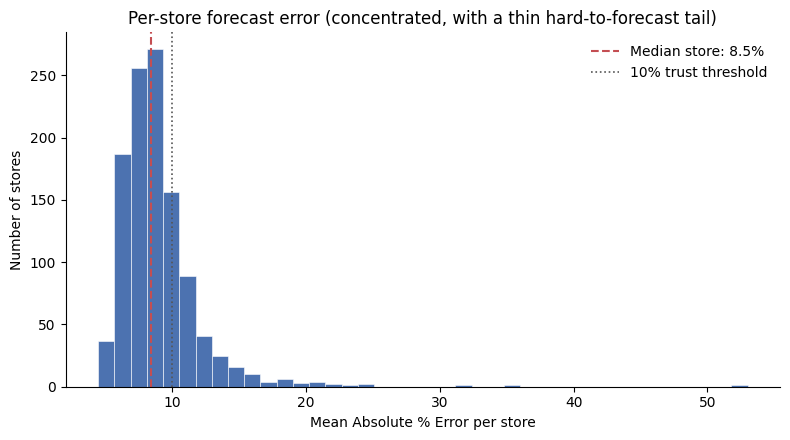

saved -> outputs/figures/05_per_store_error_dist.png


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(per_store.values * 100, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.axvline(per_store.median()*100, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Median store: {per_store.median()*100:.1f}%")
ax.axvline(10, color="#555", linestyle=":", linewidth=1.2, label="10% trust threshold")
ax.set_xlabel("Mean Absolute % Error per store")
ax.set_ylabel("Number of stores")
ax.set_title("Per-store forecast error (concentrated, with a thin hard-to-forecast tail)")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig("../outputs/figures/05_per_store_error_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> outputs/figures/05_per_store_error_dist.png")

## Summary

### Performance ladder (RMSPE: lower is better)

| Approach | RMSPE | Note |
|---|---|---|
| Naive baseline (mean per Store/DayOfWeek) | 0.236 | reference |
| LightGBM, untuned (3-fold CV) | ~0.14 | |
| **Final tuned model: CV mean** | **0.126** | expected performance, range 0.121–0.134 |
| Final tuned model: deployed (latest fold) | 0.124 | saved model, this window only |
| *Reference: strong competition solutions* | *~0.10–0.11* | *for context, not the target* |

**Headline: ~46% RMSPE reduction vs naive baseline.** Typical-day error (median APE) ~6.8%.